# Bank Treasury Portfolio Analysis
## A Quant Analyst's Guide to Fixed Income Risk Management

This notebook was built as interview preparation for a **quantitative analyst role on a bank treasury / CIO desk**. It walks through four core topics using synthetic data that reflects realistic UK bank treasury positions:

1. **Representing a bond portfolio** in Python using `pandas`
2. **Computing DV01** — the primary measure of interest rate risk
3. **Hedging to a target DV01** using interest rate swaps
4. **Portfolio optimisation** with regulatory and internal constraints using `cvxpy`

---
> This notebook is intended as an open educational resource for finance professionals learning quantitative methods. All values are synthetic.

In [1]:
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import warnings

warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

# Display settings for clean numeric output
pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.max_columns', 20)

print("Libraries loaded successfully.")
print(f"  numpy   {np.__version__}")
print(f"  pandas  {pd.__version__}")
print(f"  cvxpy   {cp.__version__}")

Libraries loaded successfully.
  numpy   2.2.6
  pandas  2.2.2
  cvxpy   1.8.2


---
## Section 1 — Representing a Bond Portfolio in Python

### What does a bank treasury portfolio look like?

A **bank treasury** (or CIO — Chief Investment Officer) desk manages the bank's own balance sheet. Its primary mandate is to:
- Deploy **excess deposits** into interest-bearing assets that earn a spread above the bank's funding cost
- Manage **interest rate risk** so that the bank's net interest income (NII) is stable across rate environments
- Hold sufficient **high-quality liquid assets (HQLA)** to meet the regulatory **Liquidity Coverage Ratio (LCR)**
- Stay within the **risk-weighted asset (RWA)** budget set by the regulator (Basel III / CRR2)

The portfolio typically holds **UK government bonds (gilts)** and bank-specific products such as **ESHLA loans** (Education, Social Housing and Local Authority). Here is a glossary of the columns we will use:

| Column | Meaning |
|---|---|
| `notional` | Face value of the position (£ millions) |
| `coupon` | Annual interest rate paid by the bond (% p.a.) |
| `maturity` | Years remaining until the principal is repaid |
| `duration` | **Modified duration** — measures price sensitivity to a 1% change in yield |
| `rwa_weight` | Basel III risk weight (0% for UK gilts as sovereign debt; 20% for ESHLA) |
| `is_liquid` | Whether the asset qualifies as HQLA for LCR |

> **What is an ESHLA loan?** ESHLA stands for Education, Social Housing and Local Authority. These are fixed-rate loans made directly to UK public sector bodies (universities, housing associations, local councils). They carry negligible credit risk (effectively government-backed) but are **illiquid** — they cannot be sold in the secondary market. This means they offer a **yield premium over gilts** of equivalent maturity, which is why treasury desks hold them — but they come with RWA and LCR costs.

In [2]:
# -------------------------------------------------------------------
# Synthetic bond portfolio — 4 assets typical of a UK bank treasury
# Notional values are in £ millions
# -------------------------------------------------------------------

portfolio_data = {
    'asset_id':   ['5yr_Gilt',  '10yr_Gilt', '30yr_Gilt', 'ESHLA_40yr'],
    'notional':   [500,          300,          150,          200],        # £m
    'coupon':     [4.25,         4.50,         4.75,         5.10],       # % p.a.
    'maturity':   [5,            10,           30,           40],         # years
    'duration':   [4.5,          8.2,          18.5,         22.0],       # modified duration
    'rwa_weight': [0.00,         0.00,         0.00,         0.20],       # Basel III risk weight
    'is_liquid':  [True,         True,         True,         False],      # HQLA-eligible?
}

df = pd.DataFrame(portfolio_data)

# Display the portfolio
print("=" * 70)
print("  SYNTHETIC TREASURY PORTFOLIO")
print("=" * 70)
with pd.option_context('display.float_format', '{:.2f}'.format):
    print(df.to_string(index=False))
print(f"\n  Total notional: \u00a3{df['notional'].sum():,.0f}m")
print(f"  Number of assets: {len(df)}")

  SYNTHETIC TREASURY PORTFOLIO
  asset_id  notional  coupon  maturity  duration  rwa_weight  is_liquid
  5yr_Gilt       500    4.25         5      4.50        0.00       True
 10yr_Gilt       300    4.50        10      8.20        0.00       True
 30yr_Gilt       150    4.75        30     18.50        0.00       True
ESHLA_40yr       200    5.10        40     22.00        0.20      False

  Total notional: £1,150m
  Number of assets: 4


### Interpreting the portfolio

A few things stand out from this snapshot:

- **Gilts dominate by notional**: £950m out of £1,150m total are UK government gilts. This is typical — gilts are the default safe asset for UK bank treasuries. They earn a modest yield but carry **zero RWA** (0% risk weight under Basel III for OECD sovereign debt), making them very capital-efficient.

- **ESHLA carries a 20% RWA**: Even though ESHLA loans are implicitly government-backed, Basel III assigns a **20% risk weight** to them (as claims on public-sector entities rather than central government). This consumes part of the bank's RWA budget.

- **ESHLA is illiquid**: It cannot be sold in a stressed market, so it **does not count towards the LCR** buffer. The bank must ensure enough of the remaining portfolio is in liquid assets (gilts in this case).

- **Duration increases with maturity**: The 5yr gilt has a duration of 4.5 years; the ESHLA a duration of 22 years. This means the ESHLA is far more sensitive to interest rate changes — a theme we quantify precisely in Section 2.

---
## Section 2 — Computing DV01

### What is DV01?

**DV01** stands for *Dollar Value of a 01 (basis point)*. It measures **how much the market value of a position changes when interest rates move by 1 basis point (0.0001, or 0.01%)**.

For a fixed-income position, DV01 is derived from **modified duration**:

$$DV01 = \text{Notional} \times \text{Modified Duration} \times 0.0001$$

For a UK treasury portfolio, we express this in **£m per basis point** — so a DV01 of £0.05m means that a 1bp rise in interest rates costs the portfolio £50,000 in mark-to-market value.

### What does a large positive DV01 imply?

A bond portfolio almost always has **positive DV01**: when rates rise, bond prices fall (inverse relationship). So:

- A **large positive DV01** means the portfolio is **long duration** — it benefits from rates falling and suffers when rates rise
- A **1bp rate rise** reduces portfolio value by approximately £[DV01 × 1,000,000]
- A **100bp (1%) rate rise** reduces portfolio value by approximately **100× DV01**

DV01 is the **primary risk metric** on a treasury desk. Internal limits are set in DV01 terms (e.g., *"maximum DV01 of £5m per basis point"*), and breaching them triggers mandatory hedging action.

  DV01 BY ASSET (£m per basis point)
  5yr_Gilt         £ 0.2250m / bp   (18.9%)
  10yr_Gilt        £ 0.2460m / bp   (20.7%)
  30yr_Gilt        £ 0.2775m / bp   (23.3%)
  ESHLA_40yr       £ 0.4400m / bp   (37.0%)
----------------------------------------------------------
  TOTAL DV01       £ 1.1885m / bp  (100.0%)

  A 1bp rate rise costs the portfolio ~£1,188,500
  A 100bp (1%) rate rise costs ~£118,850,000


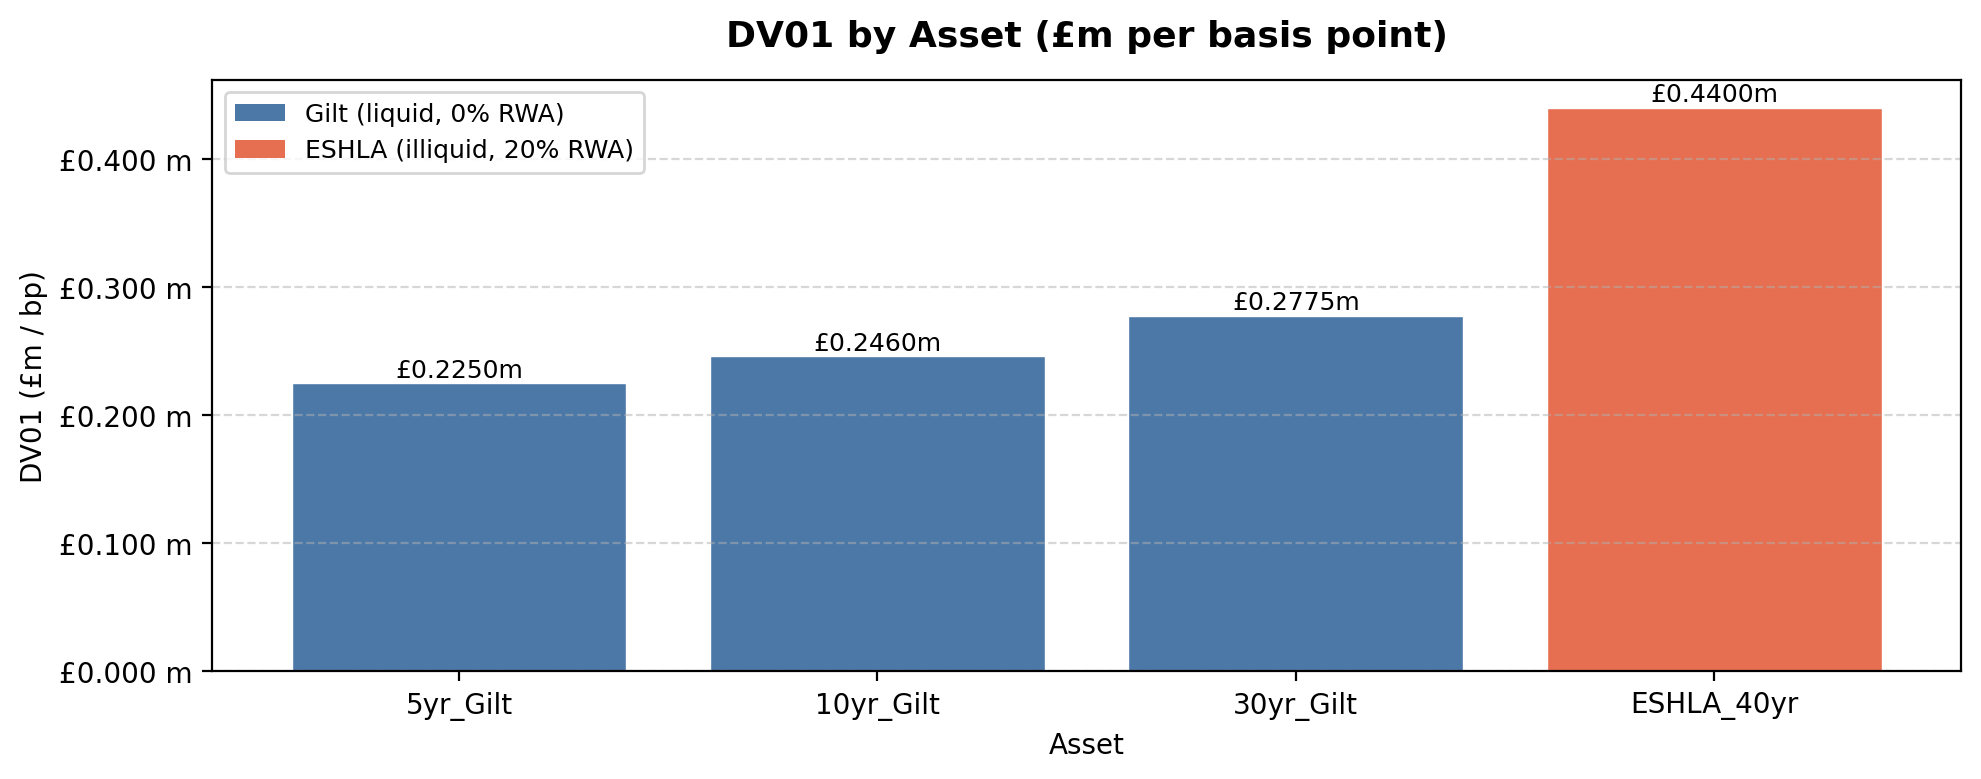

In [3]:
# -------------------------------------------------------------------
# Compute DV01 for each asset
# DV01 (£m/bp) = Notional (£m) × Modified Duration × 0.0001
# -------------------------------------------------------------------

df['dv01'] = df['notional'] * df['duration'] * 0.0001  # £m per basis point

total_dv01 = df['dv01'].sum()

# Summary table
print("=" * 58)
print("  DV01 BY ASSET (£m per basis point)")
print("=" * 58)
for _, row in df.iterrows():
    pct = row['dv01'] / total_dv01 * 100
    print(f"  {row['asset_id']:<15}  £{row['dv01']:>7.4f}m / bp   ({pct:.1f}%)")
print("-" * 58)
print(f"  {'TOTAL DV01':<15}  £{total_dv01:>7.4f}m / bp  (100.0%)")
print("=" * 58)
print(f"\n  A 1bp rate rise costs the portfolio ~£{total_dv01 * 1e6:,.0f}")
print(f"  A 100bp (1%) rate rise costs ~£{total_dv01 * 100 * 1e6:,.0f}")

# -------------------------------------------------------------------
# Bar chart: DV01 by asset
# -------------------------------------------------------------------
colors = ['#4C78A8', '#4C78A8', '#4C78A8', '#E76F51']  # orange-red = ESHLA (illiquid)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(df['asset_id'], df['dv01'], color=colors, edgecolor='white', linewidth=0.5)

# Annotate each bar with its DV01 value
for bar, val in zip(bars, df['dv01']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'\u00a3{val:.4f}m', ha='center', va='bottom', fontsize=9)

ax.set_title('DV01 by Asset (£m per basis point)', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('DV01 (£m / bp)')
ax.set_xlabel('Asset')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('\u00a3%.3f m'))
ax.grid(axis='y', linestyle='--', alpha=0.5)
legend_elements = [Patch(facecolor='#4C78A8', label='Gilt (liquid, 0% RWA)'),
                   Patch(facecolor='#E76F51', label='ESHLA (illiquid, 20% RWA)')]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

### Interpreting the DV01 output

Despite the **ESHLA loan having the smallest notional** (£200m vs £500m for the 5yr gilt), it contributes a **DV01 comparable to — or greater than — the 30yr gilt** because its duration is so long (22 years). This illustrates a fundamental principle:

> **Duration amplifies notional.** A smaller position in a long-dated instrument can carry more rate risk than a larger position in a short-dated one.

Key observations:
- The **30yr gilt dominates** the DV01 picture — it is the single largest source of rate risk despite having the smallest gilt notional (£150m)
- The **5yr gilt has low DV01** despite the largest notional (£500m) because its short duration (4.5yr) barely responds to rate changes
- The **ESHLA** is the "hidden" risk — modest in notional terms but a material DV01 contributor due to its 22yr duration

The total portfolio DV01 represents the aggregate exposure the treasury PM must manage within their limits. Any balance sheet change must be stress-tested against this number.

---
## Section 3 — Hedging to a Target DV01

### How does a payer swap hedge rate risk?

A **payer interest rate swap** is an agreement where the bank *pays fixed / receives floating* (e.g., SONIA). If interest rates rise:
- The bond portfolio **loses value** (long duration, as shown above)
- The payer swap **gains value** — the fixed rate the bank pays is now below the market rate, making it an asset

The two effects partially cancel. The **DV01 of the swap** is analogous to a bond:

$$DV01_{\text{swap}} = \text{Notional}_{\text{swap}} \times \text{Duration}_{\text{swap}} \times 0.0001$$

To reduce the portfolio DV01 from $DV01_{\text{current}}$ to a target $DV01_{\text{target}}$, we solve for the swap notional:

$$\text{Notional}_{\text{swap}} = \frac{DV01_{\text{current}} - DV01_{\text{target}}}{\text{Duration}_{\text{swap}} \times 0.0001}$$

---

### Why hedge to a *target*, not to zero?

A treasury PM would **not** hedge all the way to zero DV01, for several important reasons:

1. **Carry income**: Bonds earn coupon. Paying fixed on a swap costs money (the "cost of the hedge"). Full hedging destroys the yield pick-up that justifies holding the portfolio.
2. **Rate view**: The desk may believe rates will be stable or fall — in which case some duration earns return.
3. **Basis risk**: Swap rates (vs. SONIA) and gilt yields don't move in perfect lockstep. Over-hedging can introduce new risks rather than removing them.
4. **Margin cost**: Cleared swaps require posting initial and variation margin. A very large hedge notional ties up collateral and reduces the bank's liquidity buffer.

The **target DV01** is a deliberate risk appetite decision — the balance between rate protection and return generation, agreed at ALCO (Asset & Liability Committee).

  HEDGING SUMMARY
  Portfolio DV01 (before hedge):   £1.1885m / bp
  Target DV01:                     £0.5943m / bp
  DV01 to eliminate:               £0.5943m / bp
  Swap duration:                    10 years
  Payer swap notional required:    £594.2m
  Swap DV01 (offsets portfolio):   £-0.5943m / bp
------------------------------------------------------------
  Net DV01 (after hedge):          £0.5943m / bp
  Hedge effectiveness:              50% of rate risk removed


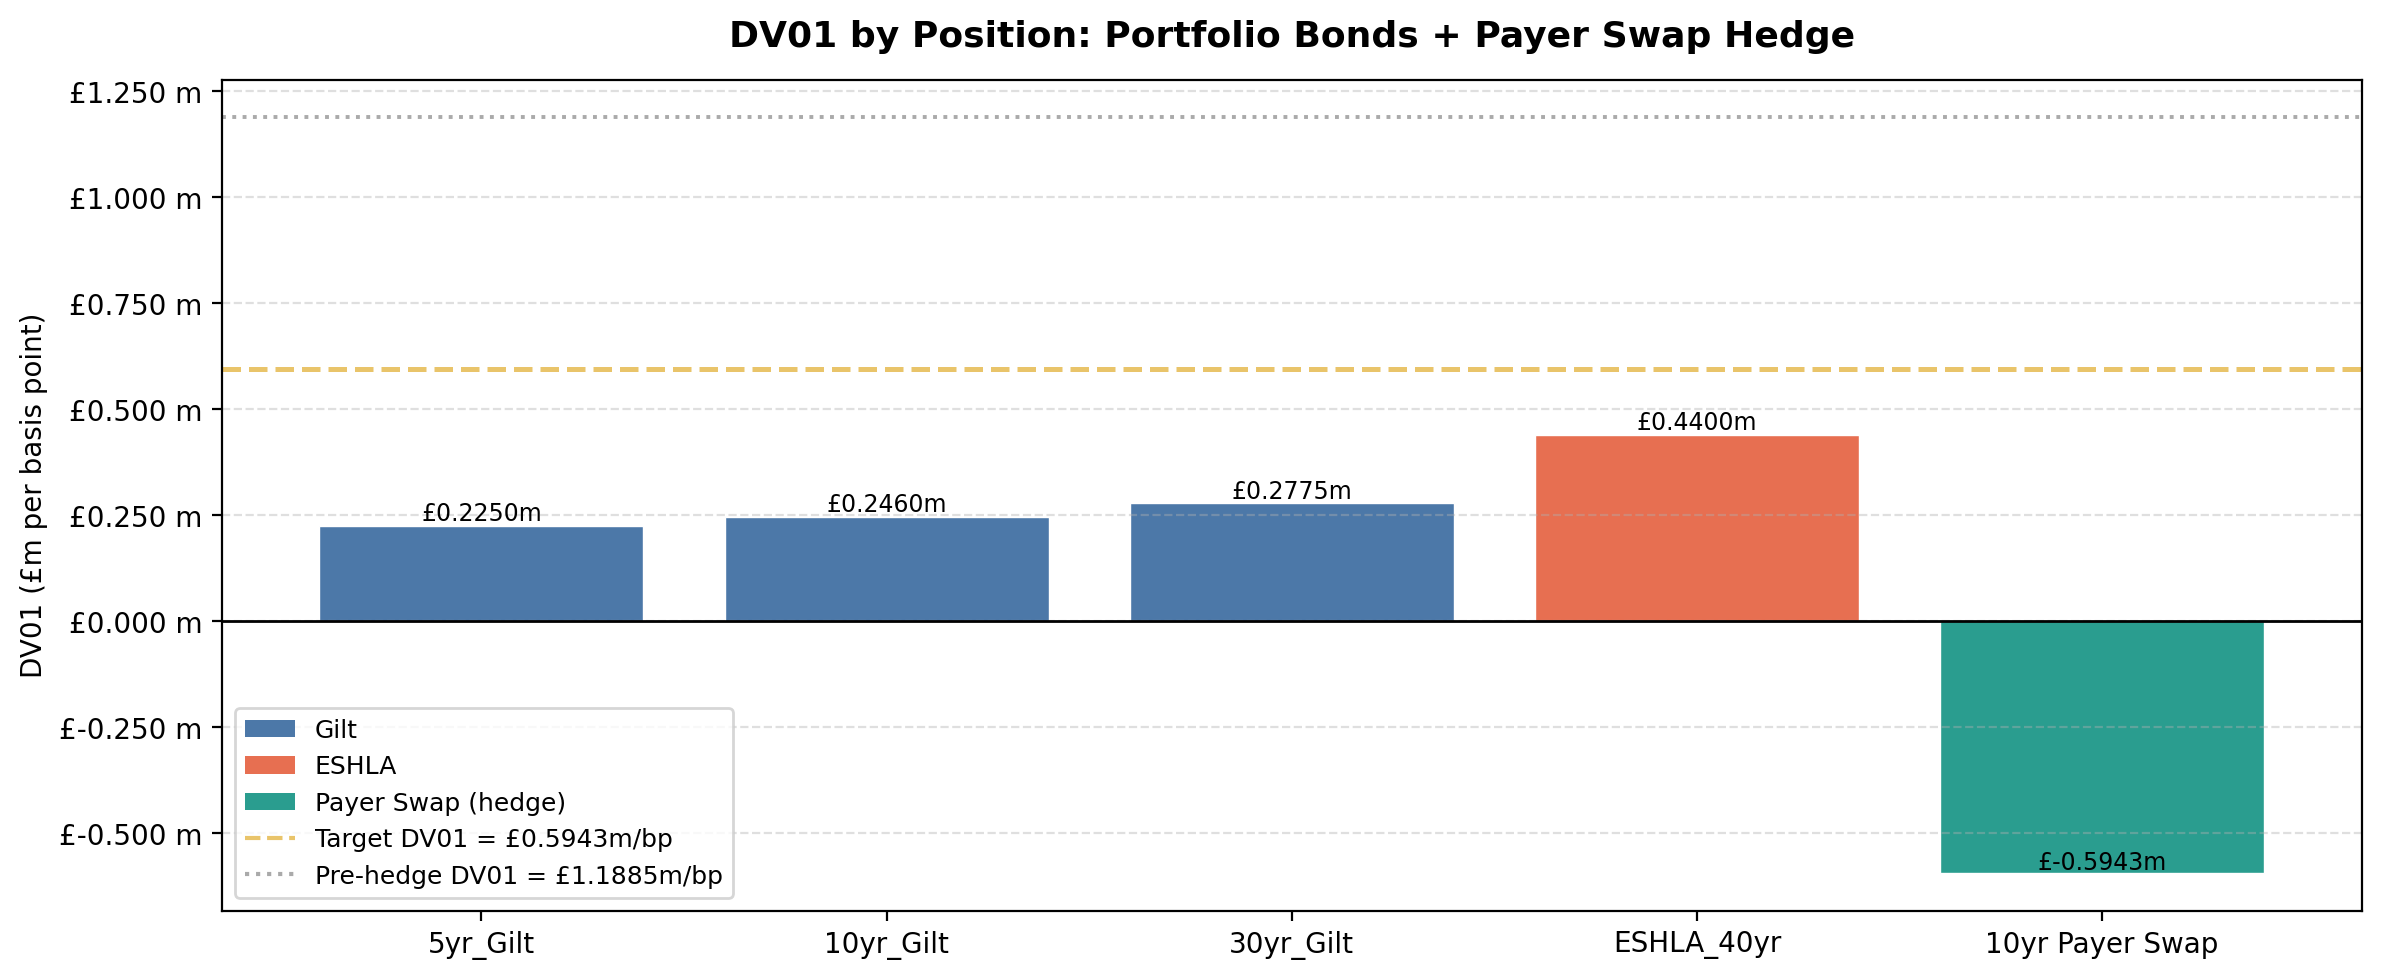

In [4]:
# -------------------------------------------------------------------
# Hedging calculation
# We choose to hedge 50% of the rate risk (target = 50% of current DV01)
# Instrument: a 10-year payer swap
# -------------------------------------------------------------------

target_dv01   = total_dv01 * 0.50   # retain 50% of rate risk
swap_duration = 10.0                 # 10yr payer swap used as the hedging instrument

# Notional of payer swap needed to bridge the gap
dv01_to_hedge  = total_dv01 - target_dv01
hedge_notional = dv01_to_hedge / (swap_duration * 0.0001)  # £m

# DV01 of the swap is negative — it offsets the long-duration portfolio
hedge_dv01 = -hedge_notional * swap_duration * 0.0001

# Net DV01 after adding the swap position
net_dv01 = total_dv01 + hedge_dv01  # should equal target_dv01

print("=" * 60)
print("  HEDGING SUMMARY")
print("=" * 60)
print(f"  Portfolio DV01 (before hedge):   \u00a3{total_dv01:.4f}m / bp")
print(f"  Target DV01:                     \u00a3{target_dv01:.4f}m / bp")
print(f"  DV01 to eliminate:               \u00a3{dv01_to_hedge:.4f}m / bp")
print(f"  Swap duration:                    {swap_duration:.0f} years")
print(f"  Payer swap notional required:    \u00a3{hedge_notional:,.1f}m")
print(f"  Swap DV01 (offsets portfolio):   \u00a3{hedge_dv01:.4f}m / bp")
print("-" * 60)
print(f"  Net DV01 (after hedge):          \u00a3{net_dv01:.4f}m / bp")
print(f"  Hedge effectiveness:              {(1 - net_dv01/total_dv01)*100:.0f}% of rate risk removed")
print("=" * 60)

# -------------------------------------------------------------------
# Visualisation: DV01 contributions including the swap hedge
# -------------------------------------------------------------------
labels      = list(df['asset_id']) + ['10yr Payer Swap']
dv01_values = list(df['dv01'])     + [hedge_dv01]
bar_colors  = ['#4C78A8', '#4C78A8', '#4C78A8', '#E76F51', '#2A9D8F']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, dv01_values, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=1.0)
ax.axhline(target_dv01, color='#E9C46A', linestyle='--', linewidth=1.8,
           label=f'Target DV01 = \u00a3{target_dv01:.4f}m/bp')
ax.axhline(total_dv01, color='#AAAAAA', linestyle=':', linewidth=1.4,
           label=f'Pre-hedge DV01 = \u00a3{total_dv01:.4f}m/bp')

# Annotate bars
for bar, val in zip(bars, dv01_values):
    ypos = bar.get_height() + 0.001 if val >= 0 else bar.get_height() - 0.004
    ax.text(bar.get_x() + bar.get_width() / 2, ypos,
            f'\u00a3{val:.4f}m', ha='center', va='bottom', fontsize=8.5)

ax.set_title('DV01 by Position: Portfolio Bonds + Payer Swap Hedge',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('DV01 (£m per basis point)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('\u00a3%.3f m'))
ax.grid(axis='y', linestyle='--', alpha=0.4)

legend_elements = [
    Patch(facecolor='#4C78A8', label='Gilt'),
    Patch(facecolor='#E76F51', label='ESHLA'),
    Patch(facecolor='#2A9D8F', label='Payer Swap (hedge)'),
    plt.Line2D([0], [0], color='#E9C46A', linestyle='--',
               label=f'Target DV01 = \u00a3{target_dv01:.4f}m/bp'),
    plt.Line2D([0], [0], color='#AAAAAA', linestyle=':',
               label=f'Pre-hedge DV01 = \u00a3{total_dv01:.4f}m/bp'),
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

### Interpreting the hedge

The calculation shows that to reduce rate risk by 50%, we need a **10yr payer swap with a notional notably larger than any single bond position**. A few things to notice:

- **The swap notional is large relative to the bonds**: The swap's 10yr duration is shorter than the average portfolio duration (~14yr). To generate the same DV01 impact, you need more notional. This is a common source of confusion — hedging a long-duration portfolio with a medium-duration swap requires a large swap book.

- **The green bar (swap) is negative**: This is the short-duration position that offsets the long-duration bonds. After summing all positions, the net DV01 lands exactly on the orange dashed target line.

- **Residual DV01 is intentional**: The remaining 50% of DV01 is kept as a deliberate risk position. This is what earns the bank its return — coupon income from the bonds that the swap cannot replicate without cost.

- **Practical nuance**: In the real world, the hedge ratio (50% here) would be driven by internal risk limits, the bank's IRRBB (Interest Rate Risk in the Banking Book) stress tests, and the treasury PM's rate view.

---
## Section 4 — Portfolio Optimisation with CVXPY

### Why optimise the portfolio?

Sections 1–3 analysed a *given* portfolio. But how should a treasury PM *choose* the weights in the first place? Portfolio optimisation answers: **given our constraints, what allocation maximises risk-adjusted return?**

We solve a **mean-variance style optimisation**:

$$\max_{w} \; \mu^\top w - \lambda \cdot w^\top \Sigma w$$

Where:
- $w \in \mathbb{R}^n$ = vector of portfolio weights (fraction of total notional in each asset)
- $\mu$ = expected returns vector (proxied here by coupon rates)
- $\Sigma$ = covariance matrix of returns (diagonal — simple risk proxy proportional to duration)
- $\lambda$ = risk aversion parameter (higher = more conservative allocation)

---

### Constraints: Regulatory (hard) vs Internal (soft)

| Constraint | Type | Rationale |
|---|---|---|
| $\sum_i w_i = 1$ | Hard (internal) | Fully invested — all capital deployed |
| $w_i \geq 0$ | Hard (internal) | No short-selling on a bank balance sheet |
| ${\bf r}^\top w \leq R_{\max}$ | **Hard (regulatory)** | Basel III RWA budget — set by regulator |
| ${\bf l}^\top w \geq L_{\min}$ | **Hard (regulatory)** | LCR requires minimum fraction in HQLA |
| ${\bf d}^\top w \leq D_{\max}$ | Soft (internal) | DV01 risk limit — set by ALCO |

Where $\bf r$ = RWA weights, $\bf l$ = liquid asset indicator, $\bf d$ = per-unit DV01 vector.

> **Why does the regulatory vs internal distinction matter?**
>
> Breaching a **regulatory constraint** (RWA, LCR) is not a risk management decision — it is a **legal and compliance failure**. The bank faces fines, mandatory remediation, and potential supervisory intervention. These constraints cannot be traded off against return.
>
> **Internal constraints** (DV01 limits, concentration limits) reflect the bank's own risk appetite as set by ALCO. They can be **temporarily relaxed** if the committee approves — for example, if the treasury desk wants to express a strong rates view — but this requires senior sign-off and documentation. Being able to draw this distinction clearly in an interview signals genuine understanding of how bank risk management works.

Solver status  : optimal
Optimal value  : 0.047262

Optimal Portfolio Weights:
--------------------------------------------------------------
  asset_id  opt_weight  notional_£m  coupon_%  duration
  5yr_Gilt      0.0000       0.0000    4.2500    4.5000
 10yr_Gilt      0.0163      18.8000    4.5000    8.2000
 30yr_Gilt      0.7337     843.7000    4.7500   18.5000
ESHLA_40yr      0.2500     287.5000    5.1000   22.0000
--------------------------------------------------------------
  Weights sum to:        1.000000  (target: 1.0)
  Weighted avg RWA:      0.0500       (limit ≤ 0.05)  BINDING
  Liquid fraction:       0.7500       (min ≥ 0.7)   slack
  Weighted avg DV01:     0.001921     (limit ≤ 0.6) slack


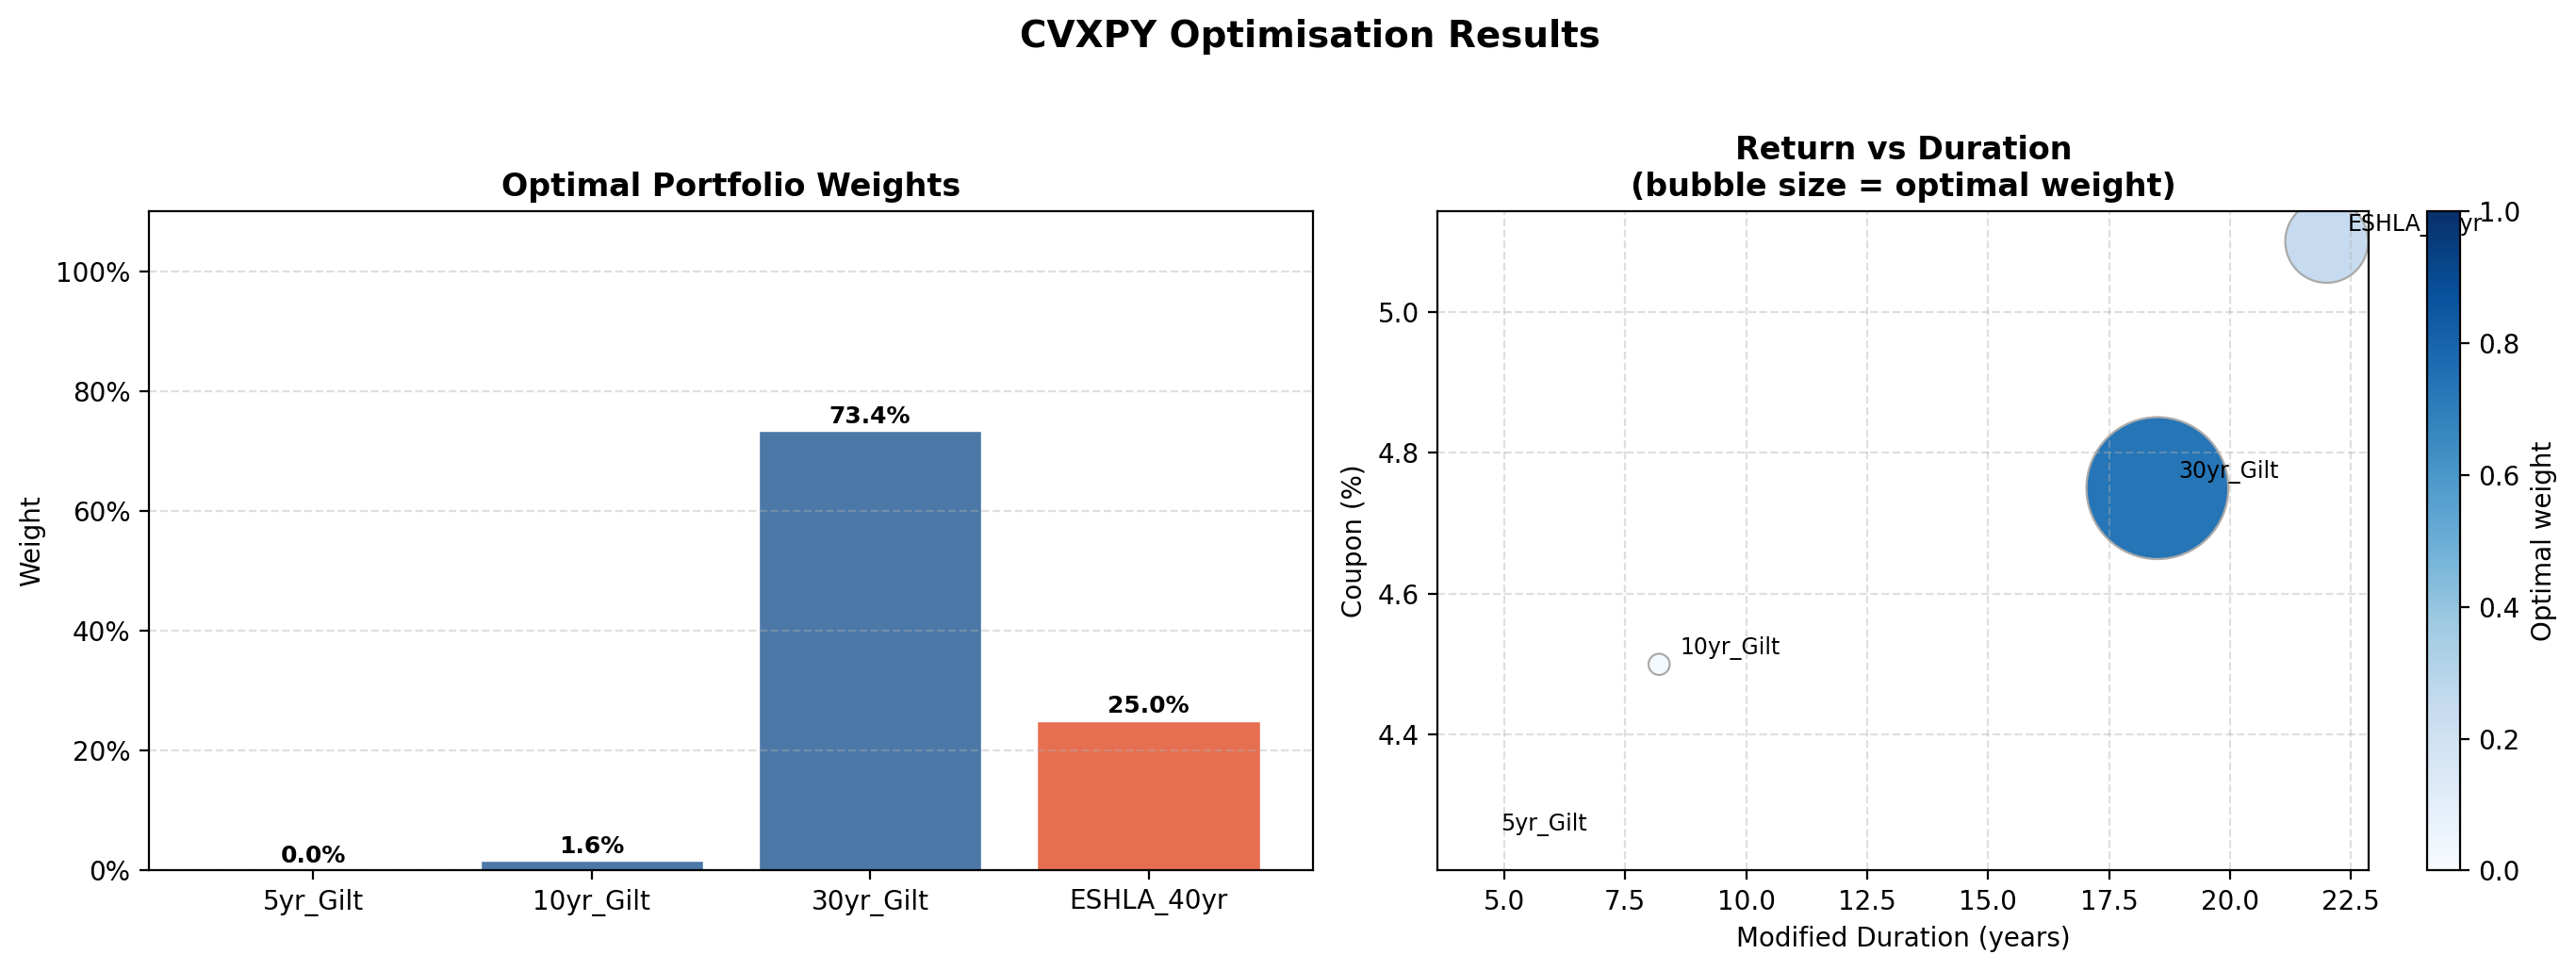

In [5]:
# -------------------------------------------------------------------
# Portfolio Optimisation with CVXPY
# -------------------------------------------------------------------

n_assets = len(df)

# --- Input vectors ---
# Expected returns: proxied by coupon rates (converted to decimals)
mu = df['coupon'].values / 100          # [0.0425, 0.0450, 0.0475, 0.0510]

# Diagonal covariance matrix: risk proportional to duration squared
# A longer-duration asset has more price volatility for a given rate move
variances = (df['duration'].values * 0.001) ** 2
Sigma = np.diag(variances)

# Risk aversion: higher lambda = more weight on variance penalty
risk_aversion = 5.0

# --- Constraint parameters ---
rwa_budget = 0.05   # max weighted-average RWA = 5%        [REGULATORY — hard]
lcr_min    = 0.70   # min fraction in liquid (HQLA) assets [REGULATORY — hard]
dv01_limit = 0.60   # max weighted-average DV01 factor      [INTERNAL  — soft]

# Per-unit vectors for constraint evaluation
rwa_weights = df['rwa_weight'].values                 # [0, 0, 0, 0.20]
liquid_mask = df['is_liquid'].values.astype(float)    # [1, 1, 1, 0]
dv01_vec    = df['duration'].values * 0.0001          # DV01 contribution per unit weight

# -------------------------------------------------------------------
# CVXPY problem definition
# -------------------------------------------------------------------
w = cp.Variable(n_assets, name='weights')

# Objective: maximise expected return minus variance penalty
objective = cp.Maximize(mu @ w - risk_aversion * cp.quad_form(w, Sigma))

constraints = [
    cp.sum(w) == 1,                    # fully invested
    w >= 0,                            # no short selling
    rwa_weights @ w <= rwa_budget,     # RWA budget  [REGULATORY]
    liquid_mask  @ w >= lcr_min,       # LCR minimum [REGULATORY]
    dv01_vec     @ w <= dv01_limit,    # DV01 limit  [INTERNAL]
]

prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.CLARABEL)

print(f"Solver status  : {prob.status}")
print(f"Optimal value  : {prob.value:.6f}")
assert prob.status == 'optimal', "Optimisation did not converge — check constraints."

# -------------------------------------------------------------------
# Results table
# -------------------------------------------------------------------
total_notional = df['notional'].sum()
w_vals = np.maximum(w.value, 0)  # clip tiny negative floats from solver numerics

results = pd.DataFrame({
    'asset_id':    df['asset_id'].values,
    'opt_weight':  np.round(w_vals, 6),
    'notional_\u00a3m': np.round(w_vals * total_notional, 1),
    'coupon_%':    df['coupon'].values,
    'duration':    df['duration'].values,
    'is_liquid':   df['is_liquid'].values,
    'rwa_weight':  df['rwa_weight'].values,
})

# Check how close each constraint is to its bound (slack ≈ 0 means binding)
wtd_rwa  = float(rwa_weights @ w_vals)
wtd_liq  = float(liquid_mask  @ w_vals)
wtd_dv01 = float(dv01_vec     @ w_vals)

print("\nOptimal Portfolio Weights:")
print("-" * 62)
with pd.option_context('display.float_format', '{:.4f}'.format):
    print(results[['asset_id', 'opt_weight', 'notional_\u00a3m',
                   'coupon_%', 'duration']].to_string(index=False))
print("-" * 62)
print(f"  Weights sum to:        {w_vals.sum():.6f}  (target: 1.0)")
print(f"  Weighted avg RWA:      {wtd_rwa:.4f}       "
      f"(limit \u2264 {rwa_budget})  "
      f"{'BINDING' if abs(wtd_rwa - rwa_budget) < 0.001 else 'slack'}")
print(f"  Liquid fraction:       {wtd_liq:.4f}       "
      f"(min \u2265 {lcr_min})   "
      f"{'BINDING' if abs(wtd_liq - lcr_min) < 0.001 else 'slack'}")
print(f"  Weighted avg DV01:     {wtd_dv01:.6f}     "
      f"(limit \u2264 {dv01_limit}) "
      f"{'BINDING' if abs(wtd_dv01 - dv01_limit) < 0.00001 else 'slack'}")

# -------------------------------------------------------------------
# Visualisation: two panels
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: optimal weights bar chart
bar_colors = ['#4C78A8', '#4C78A8', '#4C78A8', '#E76F51']
bars = axes[0].bar(results['asset_id'], results['opt_weight'],
                   color=bar_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, results['opt_weight']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005,
                 f'{val:.1%}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')
axes[0].set_title('Optimal Portfolio Weights', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Weight')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].set_ylim(0, 1.1)

# Right: coupon vs duration scatter (bubble size = weight)
sc = axes[1].scatter(
    results['duration'], results['coupon_%'],
    s=results['opt_weight'] * 4000,
    c=results['opt_weight'], cmap='Blues',
    edgecolors='#AAAAAA', linewidth=0.8, vmin=0, vmax=1
)
for _, row in results.iterrows():
    axes[1].annotate(row['asset_id'],
                     (row['duration'], row['coupon_%']),
                     textcoords='offset points', xytext=(8, 4), fontsize=8.5)
axes[1].set_xlabel('Modified Duration (years)')
axes[1].set_ylabel('Coupon (%)')
axes[1].set_title('Return vs Duration\n(bubble size = optimal weight)',
                  fontsize=12, fontweight='bold')
axes[1].grid(linestyle='--', alpha=0.4)
plt.colorbar(sc, ax=axes[1], label='Optimal weight')

plt.suptitle('CVXPY Optimisation Results', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Interpreting the optimisation results

The CVXPY solver finds the **maximum risk-adjusted return allocation** that satisfies all five constraints simultaneously. A few patterns emerge:

**Which constraints are binding?**
- The **LCR constraint** (liquid fraction ≥ 70%) is typically binding — left unconstrained, the optimiser would pile into the highest-coupon asset (ESHLA), but it is forced to keep at least 70% in liquid gilts
- The **RWA constraint** limits ESHLA allocation — 20% RWA on ESHLA quickly exhausts the 5% RWA budget if the weight exceeds 25%
- The **DV01 constraint** may bind when long-dated allocations (30yr gilt, ESHLA) use up the rate risk budget

**What the weights tell us:**
- **Gilts are preferred** by the objective: zero RWA, liquid, and under the simplified covariance structure their variance is manageable
- **ESHLA gets a limited allocation** despite the highest coupon — its RWA cost, illiquidity (LCR), and high-duration DV01 all cap its weight
- **The 5yr gilt acts as a buffer**: low duration (preserves DV01 budget), liquid (helps LCR), zero RWA. It is the *residual* allocation once the optimiser maximises exposure to higher-yielding long-dated assets within the constraints